# 🔬 OCT Segmentation — Fine-Tuning on ROI Translation Augmented Dataset




In [ ]:
!pip install -q segmentation-models-pytorch albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.6 MB/s eta 0:00:00


In [ ]:
import os, cv2, json, numpy as np, torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import pandas as pd
from google.colab import drive

# ── CONFIG ────────────────────────────────────────────────────────────────────
CONFIG = {
    # ── Split-file paths (generated by oct_dataset_split.ipynb) ──────────────
    "train_txt"     : "/content/drive/MyDrive/FYP/data/augmented_new/train.txt",
    "val_txt"       : "/content/drive/MyDrive/FYP/data/augmented_new/val.txt",
    "test_txt"      : "/content/drive/MyDrive/FYP/data/augmented_new/test.txt",

    # ── Mask folder (same filename convention as OCT) ─────────────────────────
    "mask_dir"      : "/content/drive/MyDrive/FYP/data/augmented_new/crop_mask",

    # ── Baseline checkpoint to start fine-tuning from ─────────────────────────
    "baseline_ckpt" : "/content/drive/MyDrive/FYP/model/model1_unetpp_effb4_6class_best.pth",

    # ── Output paths ──────────────────────────────────────────────────────────
    "save_path"     : "/content/drive/MyDrive/FYP/FineTune_new/finetune_unetpp_roi_best.pth",
    "pred_dir"      : "/content/drive/MyDrive/FYP/FineTune_new/finetune_roi_predictions",
    "metrics_csv"   : "/content/drive/MyDrive/FYP/FineTune_new/finetune_roi_metrics.csv",

    # ── Architecture ──────────────────────────────────────────────────────────
    "num_classes"   : 6,

    # ── Training ──────────────────────────────────────────────────────────────
    "batch_size"    : 4,      # smaller than baseline — ROI crops vary in size
    "epochs"        : 100,
    "lr"            : 1e-4,   # lower than baseline — we are fine-tuning
    "encoder_lr"    : 1e-5,
    "freeze_epochs" : 15,      # short warm-up: decoder-only for first 5 epochs
    "patience"      : 15,
    "min_delta"     : 0.001,
    "seed"          : 42,
}

NUM_CLASSES = CONFIG["num_classes"]

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device      : {device}")
print(f"NUM_CLASSES : {NUM_CLASSES}")
print(f"Batch size  : {CONFIG['batch_size']}  (variable-size crops — dynamic padding)")

Device      : cuda
NUM_CLASSES : 6
Batch size  : 4  (variable-size crops — dynamic padding)


In [ ]:
drive.mount("/content/drive")

CLASS_INFO = {
    0: {"name": "Background",    "rgb": (0,   0,   0)},
    1: {"name": "Retinal Layer", "rgb": (255, 0,   255)},  # Magenta
    2: {"name": "PED",           "rgb": (255, 255, 0)},    # Yellow
    3: {"name": "SRF",           "rgb": (255, 0,   0)},    # Red
    4: {"name": "IRF",           "rgb": (0,   0,   255)},  # Blue
    5: {"name": "RPE",           "rgb": (0,   255, 0)},    # Green
}

CLASS_NAMES = [CLASS_INFO[i]["name"] for i in range(NUM_CLASSES)]

print("── Class Mapping ──────────────────────────────────────")
for cls_id, info in CLASS_INFO.items():
    r, g, b = info["rgb"]
    print(f"  Class {cls_id}: {info['name']:<18} RGB({r:3d},{g:3d},{b:3d})")
print(f"\nNUM_CLASSES = {NUM_CLASSES}")

Mounted at /content/drive
── Class Mapping ──────────────────────────────────────
  Class 0: Background         RGB(  0,  0,  0)
  Class 1: Retinal Layer      RGB(255,  0,255)
  Class 2: PED                RGB(255,255,  0)
  Class 3: SRF                RGB(255,  0,  0)
  Class 4: IRF                RGB(  0,  0,255)
  Class 5: RPE                RGB(  0,255,  0)

NUM_CLASSES = 6


## Step 2 — Helper Functions

Identical to the baseline: `rgb_mask_to_class` converts an RGB colour-coded mask to an integer class map; `mask_to_rgb` reverses this for visualisation.


In [ ]:
def rgb_mask_to_class(mask_bgr, class_info, tolerance=40):
    """Convert a BGR colour mask → integer class label map (H, W)."""
    mask_rgb  = cv2.cvtColor(mask_bgr, cv2.COLOR_BGR2RGB)
    h, w, _   = mask_rgb.shape
    pixels    = mask_rgb.reshape(-1, 3).astype(np.float32)
    best_dist = np.full(len(pixels), np.inf)
    best_cls  = np.zeros(len(pixels), dtype=np.uint8)

    for cls_id, info in class_info.items():
        ref  = np.array(info["rgb"], dtype=np.float32)
        dist = np.linalg.norm(pixels - ref, axis=1)
        mask_better = dist < best_dist
        best_dist[mask_better] = dist[mask_better]
        best_cls[mask_better]  = cls_id

    return best_cls.reshape(h, w)


CLASS_COLORS_VIZ = [
    [0,   0,   0  ],   # 0 Background  — black
    [255, 0,   255],   # 1 Retinal     — magenta
    [255, 255, 0  ],   # 2 PED         — yellow
    [255, 0,   0  ],   # 3 SRF         — red
    [0,   0,   255],   # 4 IRF         — blue
    [0,   255, 0  ],   # 5 RPE         — green
]

def mask_to_rgb(mask_np):
    """Integer class map → RGB visualisation array."""
    h, w = mask_np.shape
    rgb  = np.zeros((h, w, 3), dtype=np.uint8)
    for c in range(NUM_CLASSES):
        rgb[mask_np == c] = CLASS_COLORS_VIZ[c]
    return rgb

print("Helper functions defined: rgb_mask_to_class, mask_to_rgb")

Helper functions defined: rgb_mask_to_class, mask_to_rgb


## Step 3 — Dataset Loader

### Key differences from the baseline `OCTDataset`

| Aspect | Baseline | This notebook |
|--------|----------|---------------|
| Image list source | `os.listdir(image_dir)` | Reads pre-split `.txt` files |
| Image size | Fixed 256 × 256 resize | **Native size preserved** |
| Batch assembly | Standard collate | **Dynamic padding collate** |

`ROIAugDataset` reads a `.txt` file produced by the split notebook.  
Each line is a full path to an OCT crop; the matching mask is found by swapping  
`/crop_oct/` → `/crop_mask/` in the path.

> If your mask folder differs from this convention, adjust `_mask_path_from_oct` below.


In [ ]:
class ROIAugDataset(Dataset):
    """Dataset for ROI translation-augmented OCT crops.

    Reads image paths from a pre-split .txt file.
    Masks are resolved automatically via path substitution.
    Images are returned at their NATIVE size (no global resize).
    """

    def __init__(self, txt_path, class_info, transform=None):
        self.class_info = class_info
        self.transform  = transform

        with open(txt_path, "r") as f:
            self.ids = [line.strip() for line in f if line.strip()]

        if len(self.ids) == 0:
            raise RuntimeError(f"No entries found in {txt_path}")

        print(f"  Loaded {len(self.ids):>5} samples from {os.path.basename(txt_path)}")

    def __len__(self):
        return len(self.ids)

    @staticmethod
    def _mask_path_from_oct(oct_path):
        """Derive the mask path from an OCT path.
        Swaps /crop_oct/ → /crop_mask/ in the full path.
        Edit this if your directory layout differs.
        """
        return oct_path.replace("/crop_oct/", "/crop_mask/")

    def __getitem__(self, idx):
        oct_path  = self.ids[idx]
        mask_path = self._mask_path_from_oct(oct_path)

        # ── Load image (grayscale) ────────────────────────────────────────────
        img = cv2.imread(oct_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"OCT image not found: {oct_path}")

        # ── Load mask (BGR colour) ────────────────────────────────────────────
        mask_bgr = cv2.imread(mask_path, cv2.IMREAD_COLOR)
        if mask_bgr is None:
            raise FileNotFoundError(f"Mask not found: {mask_path}")

        # ── Convert colour mask → integer class labels ────────────────────────
        mask = rgb_mask_to_class(mask_bgr, self.class_info)

        # ── Apply Albumentations transforms ───────────────────────────────────
        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug["image"]        # Tensor (1, H, W)
            mask = aug["mask"].long()  # Tensor (H, W)
        else:
            img  = torch.tensor(img,  dtype=torch.float32).unsqueeze(0) / 255.0
            mask = torch.tensor(mask, dtype=torch.long)

        return img, mask   # img: (1, H, W)   mask: (H, W)


# ── Albumentations pipelines (same augmentation style as baseline) ────────────
def get_transforms(train=True):
    norm = [
        A.Normalize(mean=(0.5,), std=(0.5,), max_pixel_value=255.0),
        ToTensorV2(),
    ]
    if train:
        return A.Compose([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.RandomRotate90(p=0.3),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                               rotate_limit=15, p=0.4),
            A.RandomBrightnessContrast(p=0.4),
            A.GaussNoise(p=0.3),
            A.GaussianBlur(blur_limit=3, p=0.2),
            A.GridDistortion(p=0.2),
            A.CLAHE(clip_limit=4.0, p=0.3),
            *norm,
        ])
    return A.Compose(norm)


print("ROIAugDataset and get_transforms defined.")

ROIAugDataset and get_transforms defined.


## Step 4 — Dynamic-Padding Collate Function

Because ROI crops have variable spatial dimensions, we cannot use PyTorch's default  
collate (which assumes all tensors in a batch share the same shape).  

`pad_collate_fn` pads every image and mask in a mini-batch to the **maximum height  
and width** present in that batch. Padding values:

- **Image** → `0.0` (black, already normalised)  
- **Mask** → `0` (Background class — ignored at boundaries)

The model never sees the padded pixels as foreground, and loss contributions from  
padded pixels are zero (they are all class 0 which is heavily down-weighted).


In [ ]:
def pad_to_multiple(x, multiple=32):
    """Return the smallest integer >= x that is divisible by `multiple`."""
    return int(np.ceil(x / multiple) * multiple)


def pad_collate_fn(batch):
    """Collate variable-size (img, mask) pairs with stride-safe padding.

    SMP's EfficientNet encoder has output_stride=32, so every spatial
    dimension fed to the network must be divisible by 32.

    Strategy:
      1. Find the maximum H and W in this mini-batch.
      2. Snap both up to the next multiple of 32.
      3. Pad every sample to that (H32, W32) with right/bottom padding.

    Padding values:
      img  → 0.0  (black, already normalised — encoder ignores blank borders)
      mask → 0    (Background class; loss weight is smallest for class 0)
    """
    imgs, masks = zip(*batch)

    # ── Step 1 & 2: stride-safe target size ───────────────────────────────────
    max_h = max(img.shape[1] for img in imgs)
    max_w = max(img.shape[2] for img in imgs)
    target_h = pad_to_multiple(max_h, 32)   # e.g. 482 → 512
    target_w = pad_to_multiple(max_w, 32)   # e.g. 570 → 576

    # ── Step 3: pad each sample ───────────────────────────────────────────────
    padded_imgs  = []
    padded_masks = []

    for img, mask in zip(imgs, masks):
        _, h, w = img.shape
        pad_h   = target_h - h
        pad_w   = target_w - w
        # F.pad order: (left, right, top, bottom)
        padded_imgs.append(F.pad(img,   (0, pad_w, 0, pad_h), value=0.0))
        padded_masks.append(F.pad(mask, (0, pad_w, 0, pad_h), value=0))

    return torch.stack(padded_imgs), torch.stack(padded_masks)


# ── Build datasets ────────────────────────────────────────────────────────────
print("Loading split datasets ...")
train_ds = ROIAugDataset(CONFIG["train_txt"], CLASS_INFO, transform=get_transforms(train=True))
val_ds   = ROIAugDataset(CONFIG["val_txt"],   CLASS_INFO, transform=get_transforms(train=False))
test_ds  = ROIAugDataset(CONFIG["test_txt"],  CLASS_INFO, transform=get_transforms(train=False))

# ── Build dataloaders ─────────────────────────────────────────────────────────
pin = torch.cuda.is_available()
train_loader = DataLoader(
    train_ds, batch_size=CONFIG["batch_size"], shuffle=True,
    num_workers=2, pin_memory=pin, collate_fn=pad_collate_fn
)
val_loader = DataLoader(
    val_ds, batch_size=CONFIG["batch_size"], shuffle=False,
    num_workers=2, pin_memory=pin, collate_fn=pad_collate_fn
)
test_loader = DataLoader(
    test_ds, batch_size=CONFIG["batch_size"], shuffle=False,
    num_workers=2, pin_memory=pin, collate_fn=pad_collate_fn
)

print(f"\nTrain : {len(train_ds):>5} images")
print(f"Val   : {len(val_ds):>5} images")
print(f"Test  : {len(test_ds):>5} images")
print(f"\nBatches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

# ── Quick shape sanity check ──────────────────────────────────────────────────
sample_imgs, sample_masks = next(iter(train_loader))
print(f"\nSample batch shapes (must be divisible by 32):")
print(f"  imgs  : {tuple(sample_imgs.shape)}   dtype={sample_imgs.dtype}")
print(f"  masks : {tuple(sample_masks.shape)}   dtype={sample_masks.dtype}")
assert sample_imgs.shape[2] % 32 == 0 and sample_imgs.shape[3] % 32 == 0, \
    "Padding failed — dimensions not divisible by 32!"
print(f"  ✅ H and W both divisible by 32")
print(f"  Unique classes in sample masks: {sample_masks.unique().tolist()}")

Loading split datasets ...
  Loaded  3419 samples from train.txt
  Loaded   787 samples from val.txt
  Loaded   728 samples from test.txt

Train :  3419 images
Val   :   787 images
Test  :   728 images

Batches — Train: 855 | Val: 197 | Test: 182

Sample batch shapes (must be divisible by 32):
  imgs  : (4, 1, 160, 256)   dtype=torch.float32
  masks : (4, 160, 256)   dtype=torch.int64
  ✅ H and W both divisible by 32
  Unique classes in sample masks: [0, 1, 2, 3, 4, 5]


## Step 5 — Model · Load Baseline Checkpoint

We build the **same** UNet++ EfficientNet-B4 architecture as the baseline and then  
load the pre-trained weights. This is the starting point for fine-tuning.

> If the baseline checkpoint is not available, set `LOAD_BASELINE = False` and the  
> model will initialise from ImageNet weights (same as baseline training from scratch).


In [ ]:
LOAD_BASELINE = True   # set False to train from ImageNet weights

model = smp.UnetPlusPlus(
    encoder_name          = "efficientnet-b4",
    encoder_weights       = "imagenet",
    in_channels           = 1,
    classes               = NUM_CLASSES,
    activation            = None,
    decoder_channels      = (256, 128, 64, 32, 16),
    decoder_use_batchnorm = True,
)
model = model.to(device)

total = sum(p.numel() for p in model.parameters())
print(f"Model        : UNet++ EfficientNet-B4")
print(f"Classes      : {NUM_CLASSES}")
print(f"Total params : {total:,} ({total/1e6:.1f}M)")

# ── Load baseline checkpoint ──────────────────────────────────────────────────
if LOAD_BASELINE:
    ckpt_path = CONFIG["baseline_ckpt"]
    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ckpt["model_state"])
        print(f"\n✅ Loaded baseline checkpoint")
        print(f"   Epoch : {ckpt.get('epoch', '?')}")
        print(f"   Val Dice (baseline) : {ckpt.get('dice', '?'):.4f}")
    else:
        print(f"\n⚠️  Baseline checkpoint not found at:\n   {ckpt_path}")
        print("   Starting from ImageNet weights instead.")
else:
    print("\nLOAD_BASELINE=False — starting from ImageNet weights.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Model        : UNet++ EfficientNet-B4
Classes      : 6
Total params : 20,812,974 (20.8M)

✅ Loaded baseline checkpoint
   Epoch : 16
   Val Dice (baseline) : 0.8270


## Step 6 — Loss Function · Metric Functions

Identical structure to the baseline:

- `DiceLoss` — soft multiclass Dice
- `CombinedLoss` — 0.5 × CrossEntropy + 0.5 × Dice (same α as baseline)
- Class weights computed from the augmented mask folder

Added metrics beyond the baseline (Pixel Accuracy, Sensitivity, Specificity):
these are computed per batch and averaged over the full test set in Step 10.


In [ ]:
# ── Class weights (estimated from mask folder) ───────────────────────────────
def compute_class_weights(mask_dir, class_info, n_classes, n_samples=200):
    """Sample up to n_samples masks and compute inverse-frequency weights."""
    counts = np.zeros(n_classes, dtype=np.float64)
    files  = sorted([
        f for f in os.listdir(mask_dir)
        if f.lower().endswith((".png", ".jpg", ".tif", ".bmp"))
    ])[:n_samples]

    for fname in files:
        mask_bgr = cv2.imread(os.path.join(mask_dir, fname), cv2.IMREAD_COLOR)
        if mask_bgr is None:
            continue
        cls_mask = rgb_mask_to_class(mask_bgr, class_info)
        for c in range(n_classes):
            counts[c] += np.sum(cls_mask == c)

    freq    = counts / (counts.sum() + 1e-12)
    median  = np.median(freq)
    weights = median / (freq + 1e-6)
    weights = np.clip(weights, 0.1, 10.0)
    weights = weights / weights.sum() * n_classes

    print("── Class Weights ──────────────────────────────────────")
    for i, (cnt, w) in enumerate(zip(counts, weights)):
        pct  = 100 * cnt / (counts.sum() + 1e-12)
        name = class_info[i]["name"]
        print(f"  Class {i} {name:<18}: {pct:5.1f}%  → weight {w:.4f}")

    return torch.tensor(weights, dtype=torch.float32).to(device)

CLASS_WEIGHTS = compute_class_weights(
    CONFIG["mask_dir"], CLASS_INFO, NUM_CLASSES
)

# ── Loss modules ──────────────────────────────────────────────────────────────
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds   = F.softmax(preds, dim=1)
        one_hot = F.one_hot(targets, NUM_CLASSES).permute(0, 3, 1, 2).float()
        inter   = (preds * one_hot).sum(dim=(2, 3))
        union   = preds.sum(dim=(2, 3)) + one_hot.sum(dim=(2, 3))
        dice    = (2.0 * inter + self.smooth) / (union + self.smooth)
        return 1.0 - dice.mean()

class CombinedLoss(nn.Module):
    def __init__(self, weights, alpha=0.5):
        super().__init__()
        self.ce    = nn.CrossEntropyLoss(weight=weights)
        self.dice  = DiceLoss()
        self.alpha = alpha

    def forward(self, preds, targets):
        return self.alpha * self.ce(preds, targets)              + (1 - self.alpha) * self.dice(preds, targets)

criterion = CombinedLoss(weights=CLASS_WEIGHTS, alpha=0.5)

# ── Metric functions (same style as baseline + extended) ──────────────────────
def dice_score(preds, targets, smooth=1e-6):
    preds  = preds.argmax(dim=1)
    scores = []
    for c in range(NUM_CLASSES):
        p     = (preds == c).float()
        t     = (targets == c).float()
        inter = (p * t).sum()
        scores.append((2 * inter + smooth) / (p.sum() + t.sum() + smooth))
    return torch.stack(scores).mean().item()

def iou_score(preds, targets, smooth=1e-6):
    preds  = preds.argmax(dim=1)
    scores = []
    for c in range(NUM_CLASSES):
        p     = (preds == c).float()
        t     = (targets == c).float()
        inter = (p * t).sum()
        union = p.sum() + t.sum() - inter
        scores.append((inter + smooth) / (union + smooth))
    return torch.stack(scores).mean().item()

def per_class_dice(preds, targets, smooth=1e-6):
    preds  = preds.argmax(dim=1)
    scores = []
    for c in range(NUM_CLASSES):
        p     = (preds == c).float()
        t     = (targets == c).float()
        inter = (p * t).sum()
        scores.append(((2 * inter + smooth) / (p.sum() + t.sum() + smooth)).item())
    return scores

def per_class_iou(preds, targets, smooth=1e-6):
    preds  = preds.argmax(dim=1)
    scores = []
    for c in range(NUM_CLASSES):
        p     = (preds == c).float()
        t     = (targets == c).float()
        inter = (p * t).sum()
        union = p.sum() + t.sum() - inter
        scores.append(((inter + smooth) / (union + smooth)).item())
    return scores

def pixel_accuracy(preds, targets):
    """Fraction of correctly classified pixels."""
    preds   = preds.argmax(dim=1)
    correct = (preds == targets).float().sum()
    total   = torch.tensor(targets.numel(), dtype=torch.float32)
    return (correct / total).item()

def sensitivity_specificity(preds, targets, smooth=1e-6):
    """Mean sensitivity (recall) and specificity across all classes."""
    preds = preds.argmax(dim=1)
    sens_list, spec_list = [], []
    for c in range(NUM_CLASSES):
        tp = ((preds == c) & (targets == c)).float().sum()
        fn = ((preds != c) & (targets == c)).float().sum()
        tn = ((preds != c) & (targets != c)).float().sum()
        fp = ((preds == c) & (targets != c)).float().sum()
        sens_list.append(((tp + smooth) / (tp + fn + smooth)).item())
        spec_list.append(((tn + smooth) / (tn + fp + smooth)).item())
    return float(np.mean(sens_list)), float(np.mean(spec_list))

# ── Sanity check ──────────────────────────────────────────────────────────────
dummy_pred = torch.randn(2, NUM_CLASSES, 64, 64).to(device)
dummy_mask = torch.randint(0, NUM_CLASSES, (2, 64, 64)).to(device)
test_loss  = criterion(dummy_pred, dummy_mask)
print(f"\nSanity check loss : {test_loss.item():.4f}")
print("PASS ✓" if test_loss.item() > 0 else "FAIL ✗")

── Class Weights ──────────────────────────────────────
  Class 0 Background        :  92.5%  → weight 0.0642
  Class 1 Retinal Layer     :   0.8%  → weight 1.4605
  Class 2 PED               :   2.7%  → weight 0.4104
  Class 3 SRF               :   0.5%  → weight 2.3568
  Class 4 IRF               :   2.6%  → weight 0.4286
  Class 5 RPE               :   0.9%  → weight 1.2795

Sanity check loss : 1.5172
PASS ✓


## Step 7 — Optimizer · Scheduler · Freeze Strategy

Same two-phase freeze strategy as the baseline:

| Phase | Epochs | What trains |
|-------|--------|-------------|
| 1 (warm-up) | 1 – `freeze_epochs` | Decoder + head only (encoder frozen) |
| 2 (full) | `freeze_epochs+1` – end | Entire network, encoder at lower LR |

Fine-tuning uses **lower learning rates** than baseline training to avoid  
catastrophic forgetting of the baseline's learned features.


In [ ]:
def freeze_encoder(m):
    for p in m.encoder.parameters():
        p.requires_grad = False
    print("Encoder FROZEN   (decoder-only warm-up)")

def unfreeze_encoder(m):
    for p in m.encoder.parameters():
        p.requires_grad = True
    print("Encoder UNFROZEN (full fine-tuning)")

def make_optimizer(m, frozen=False):
    if frozen:
        return torch.optim.AdamW(
            filter(lambda p: p.requires_grad, m.parameters()),
            lr=CONFIG["lr"], weight_decay=1e-4
        )
    return torch.optim.AdamW([
        {"params": m.encoder.parameters(),         "lr": CONFIG["encoder_lr"]},
        {"params": m.decoder.parameters(),         "lr": CONFIG["lr"]},
        {"params": m.segmentation_head.parameters(),"lr": CONFIG["lr"]},
    ], weight_decay=1e-4)

print("freeze_encoder / unfreeze_encoder / make_optimizer defined.")

freeze_encoder / unfreeze_encoder / make_optimizer defined.


## Step 8 — Training & Validation Loop

`run_epoch` follows the **same pattern** as the baseline:

- `train=True`  → gradient update, grad clipping at 1.0
- `train=False` → inference only under `torch.no_grad()`

The training loop saves a checkpoint whenever val Dice improves by `min_delta`  
and applies early stopping after `patience` epochs without improvement.


In [ ]:
def run_epoch(loader, optimizer=None, train=True):
    """Run one full epoch; return (loss, dice, iou)."""
    model.train() if train else model.eval()
    total_loss = total_dice = total_iou = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            loss  = criterion(preds, masks)
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item()
            total_dice += dice_score(preds.detach(), masks)
            total_iou  += iou_score(preds.detach(),  masks)
    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n


# ── Training setup ────────────────────────────────────────────────────────────
history    = {"train_loss": [], "val_loss": [], "val_dice": [], "val_iou": []}
best_dice  = 0.0
no_improve = 0
PATIENCE   = CONFIG["patience"]
MIN_DELTA  = CONFIG["min_delta"]
FREEZE_EP  = CONFIG["freeze_epochs"]

freeze_encoder(model)
optimizer = make_optimizer(model, frozen=True)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=FREEZE_EP, eta_min=1e-6)

os.makedirs(os.path.dirname(CONFIG["save_path"]), exist_ok=True)

print(f"\nFine-tuning UNet++ on ROI translation-augmented dataset")
print(f"Phase 1 — Epochs 1–{FREEZE_EP}: decoder only")
print(f"{'Epoch':>6} {'Train Loss':>11} {'Val Loss':>10} "
      f"{'Val Dice':>10} {'Val IoU':>9}  Status")
print("-" * 65)

for epoch in range(1, CONFIG["epochs"] + 1):

    if epoch == FREEZE_EP + 1:
        unfreeze_encoder(model)
        optimizer = make_optimizer(model, frozen=False)
        scheduler = CosineAnnealingWarmRestarts(
            optimizer, T_0=10, T_mult=2, eta_min=1e-6
        )
        print(f"\nPhase 2 — full fine-tuning from epoch {epoch}\n")
        print(f"{'Epoch':>6} {'Train Loss':>11} {'Val Loss':>10} "
              f"{'Val Dice':>10} {'Val IoU':>9}  Status")
        print("-" * 65)

    tr_loss, _, _               = run_epoch(train_loader, optimizer, train=True)
    val_loss, val_dice, val_iou = run_epoch(val_loader,   train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)
    history["val_iou"].append(val_iou)

    if val_dice > best_dice + MIN_DELTA:
        best_dice  = val_dice
        no_improve = 0
        torch.save({
            "epoch"      : epoch,
            "model_state": model.state_dict(),
            "dice"       : best_dice,
            "config"     : CONFIG,
        }, CONFIG["save_path"])
        status = "✅ saved"
    else:
        no_improve += 1
        status      = f"no imp {no_improve}/{PATIENCE}"

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>6} {tr_loss:>11.4f} {val_loss:>10.4f} "
              f"{val_dice:>10.4f} {val_iou:>9.4f}  {status}")

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
        break

print(f"\nFine-tuning complete")
print(f"Best Val Dice : {best_dice:.4f}")
print(f"Checkpoint    : {CONFIG['save_path']}")

# ── Save training history ─────────────────────────────────────────────────────
hist_path = CONFIG["save_path"].replace(".pth", "_history.json")
with open(hist_path, "w") as f:
    json.dump(history, f)
print(f"History saved → {hist_path}")

Encoder FROZEN   (decoder-only warm-up)

Fine-tuning UNet++ on ROI translation-augmented dataset
Phase 1 — Epochs 1–15: decoder only
 Epoch  Train Loss   Val Loss   Val Dice   Val IoU  Status
-----------------------------------------------------------------
     1      0.6843     0.3968     0.6279    0.5409  ✅ saved
     5      0.4510     0.3184     0.6662    0.5815  no imp 1/15
    10      0.4051     0.2951     0.7067    0.6253  ✅ saved
    15      0.3840     0.2724     0.7074    0.6257  no imp 3/15
Encoder UNFROZEN (full fine-tuning)

Phase 2 — full fine-tuning from epoch 16

 Epoch  Train Loss   Val Loss   Val Dice   Val IoU  Status
-----------------------------------------------------------------
    20      0.3616     0.2603     0.7472    0.6700  ✅ saved
    25      0.3303     0.2386     0.7419    0.6630  no imp 5/15
    30      0.3242     0.2439     0.7615    0.6838  ✅ saved
    35      0.2981     0.2215     0.7552    0.6758  no imp 5/15
    40      0.2734     0.2070     0.7670  

## Step 9 — Training Report Plots

Same 6-panel layout as the baseline training report:

1. Train / Val Loss with unfreeze marker  
2. Validation Dice with best-epoch line  
3. Validation IoU  
4. Overfitting monitor (loss gap)  
5. Per-epoch Dice delta  
6. Summary statistics table


/tmp/ipykernel_993/124581414.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


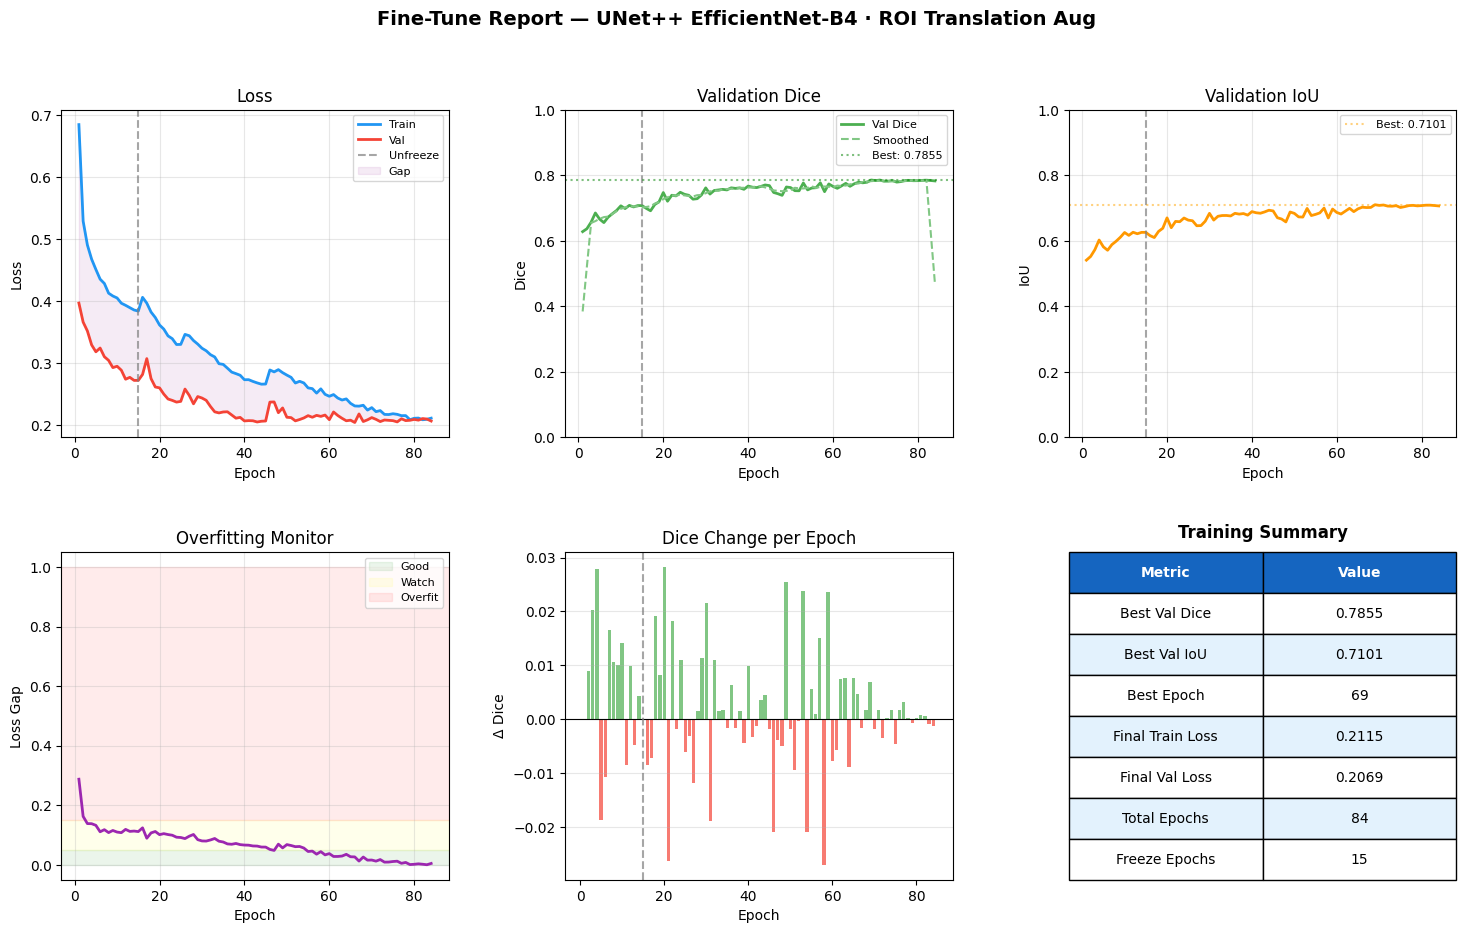

Saved → /content/drive/MyDrive/FYP/FineTune_new/finetune_roi_training_report.png


In [ ]:
# ── Reload history if running this cell independently ────────────────────────
# hist_path = CONFIG["save_path"].replace(".pth", "_history.json")
# with open(hist_path) as f:
#     history = json.load(f)

epochs    = list(range(1, len(history["train_loss"]) + 1))
freeze_ep = CONFIG["freeze_epochs"]

fig = plt.figure(figsize=(18, 10))
fig.suptitle("Fine-Tune Report — UNet++ EfficientNet-B4 · ROI Translation Aug",
             fontsize=14, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

# 1 — Loss ────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs, history["train_loss"], label="Train", color="#2196F3", linewidth=2)
ax1.plot(epochs, history["val_loss"],   label="Val",   color="#F44336", linewidth=2)
ax1.axvline(x=freeze_ep, color="gray", linestyle="--", alpha=0.7, label="Unfreeze")
ax1.fill_between(epochs, history["train_loss"], history["val_loss"],
                 alpha=0.08, color="purple", label="Gap")
ax1.set_title("Loss"); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")

# 2 — Val Dice ────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs, history["val_dice"], color="#4CAF50", linewidth=2, label="Val Dice")
if len(epochs) >= 5:
    smoothed = np.convolve(history["val_dice"], np.ones(5)/5, mode="same")
    ax2.plot(epochs, smoothed, color="#81C784", linewidth=1.5,
             linestyle="--", label="Smoothed")
ax2.axvline(x=freeze_ep, color="gray", linestyle="--", alpha=0.7)
ax2.axhline(y=max(history["val_dice"]), color="green", linestyle=":",
            alpha=0.5, label=f"Best: {max(history['val_dice']):.4f}")
ax2.set_title("Validation Dice"); ax2.legend(fontsize=8)
ax2.grid(alpha=0.3); ax2.set_ylim([0, 1])
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Dice")

# 3 — Val IoU ─────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(epochs, history["val_iou"], color="#FF9800", linewidth=2)
ax3.axvline(x=freeze_ep, color="gray", linestyle="--", alpha=0.7)
ax3.axhline(y=max(history["val_iou"]), color="orange", linestyle=":",
            alpha=0.5, label=f"Best: {max(history['val_iou']):.4f}")
ax3.set_title("Validation IoU"); ax3.legend(fontsize=8)
ax3.grid(alpha=0.3); ax3.set_ylim([0, 1])
ax3.set_xlabel("Epoch"); ax3.set_ylabel("IoU")

# 4 — Overfitting monitor ──────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
gap = [abs(t - v) for t, v in zip(history["train_loss"], history["val_loss"])]
ax4.plot(epochs, gap, color="#9C27B0", linewidth=2)
ax4.axhspan(0,    0.05, alpha=0.08, color="green",  label="Good")
ax4.axhspan(0.05, 0.15, alpha=0.08, color="yellow", label="Watch")
ax4.axhspan(0.15, 1.00, alpha=0.08, color="red",    label="Overfit")
ax4.set_title("Overfitting Monitor"); ax4.legend(fontsize=8)
ax4.grid(alpha=0.3); ax4.set_xlabel("Epoch"); ax4.set_ylabel("Loss Gap")

# 5 — Dice delta ──────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
dice_delta = [0] + [history["val_dice"][i] - history["val_dice"][i - 1]
                    for i in range(1, len(history["val_dice"]))]
colors = ["#4CAF50" if d >= 0 else "#F44336" for d in dice_delta]
ax5.bar(epochs, dice_delta, color=colors, alpha=0.7)
ax5.axhline(y=0, color="black", linewidth=0.8)
ax5.axvline(x=freeze_ep, color="gray", linestyle="--", alpha=0.7)
ax5.set_title("Dice Change per Epoch"); ax5.grid(alpha=0.3, axis="y")
ax5.set_xlabel("Epoch"); ax5.set_ylabel("Δ Dice")

# 6 — Summary table ───────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis("off")
best_ep  = history["val_dice"].index(max(history["val_dice"])) + 1
summary  = [
    ["Metric",           "Value"],
    ["Best Val Dice",    f"{max(history['val_dice']):.4f}"],
    ["Best Val IoU",     f"{max(history['val_iou']):.4f}"],
    ["Best Epoch",       str(best_ep)],
    ["Final Train Loss", f"{history['train_loss'][-1]:.4f}"],
    ["Final Val Loss",   f"{history['val_loss'][-1]:.4f}"],
    ["Total Epochs",     str(len(epochs))],
    ["Freeze Epochs",    str(freeze_ep)],
]
table = ax6.table(cellText=summary[1:], colLabels=summary[0],
                  cellLoc="center", loc="center", bbox=[0, 0, 1, 1])
table.auto_set_font_size(False); table.set_fontsize(10)
for j in range(2):
    table[0, j].set_facecolor("#1565C0")
    table[0, j].set_text_props(color="white", fontweight="bold")
for i in range(1, len(summary)):
    for j in range(2):
        table[i, j].set_facecolor("#E3F2FD" if i % 2 == 0 else "white")
ax6.set_title("Training Summary", fontweight="bold", pad=10)

report_path = "/content/drive/MyDrive/FYP/FineTune_new/finetune_roi_training_report.png"
plt.tight_layout()
plt.savefig(report_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {report_path}")

## Step 10 — Test-Set Evaluation

Full evaluation on the held-out test set using the **best saved checkpoint**.

Metrics computed per batch and averaged across all batches:

| Metric | Formula |
|--------|---------|
| Dice | 2·TP / (2·TP + FP + FN) |
| IoU | TP / (TP + FP + FN) |
| Pixel Accuracy | correct pixels / total pixels |
| Sensitivity | TP / (TP + FN) — true positive rate |
| Specificity | TN / (TN + FP) — true negative rate |

Results are saved to `finetune_roi_metrics.csv` on Google Drive.


In [ ]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
ckpt = torch.load(CONFIG["save_path"], map_location=device)
model.load_state_dict(ckpt["model_state"])
print(f"Loaded checkpoint — epoch {ckpt['epoch']} "
      f"(Val Dice = {ckpt['dice']:.4f})\n")

# ── Aggregated test metrics ────────────────────────────────────────────────────
all_loss      = 0.0
all_dice      = 0.0
all_iou       = 0.0
all_pix_acc   = 0.0
all_sens      = 0.0
all_spec      = 0.0
all_cls_dice  = [0.0] * NUM_CLASSES
all_cls_iou   = [0.0] * NUM_CLASSES
n_batches     = 0

model.eval()
with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds       = model(imgs)
        loss        = criterion(preds, masks)

        all_loss    += loss.item()
        all_dice    += dice_score(preds, masks)
        all_iou     += iou_score(preds, masks)
        all_pix_acc += pixel_accuracy(preds, masks)
        s, sp        = sensitivity_specificity(preds, masks)
        all_sens    += s
        all_spec    += sp

        for c, (cd, ci) in enumerate(zip(per_class_dice(preds, masks),
                                         per_class_iou(preds, masks))):
            all_cls_dice[c] += cd
            all_cls_iou[c]  += ci

        n_batches += 1

# ── Averages ──────────────────────────────────────────────────────────────────
test_loss    = all_loss    / n_batches
test_dice    = all_dice    / n_batches
test_iou     = all_iou     / n_batches
test_pix_acc = all_pix_acc / n_batches
test_sens    = all_sens    / n_batches
test_spec    = all_spec    / n_batches
cls_dice_avg = [s / n_batches for s in all_cls_dice]
cls_iou_avg  = [s / n_batches for s in all_cls_iou]

# ── Print results ─────────────────────────────────────────────────────────────
print("── Test Set Results ──────────────────────────────────────────────")
print(f"  Loss             : {test_loss:.4f}")
print(f"  Dice Score       : {test_dice:.4f}")
print(f"  IoU              : {test_iou:.4f}")
print(f"  Pixel Accuracy   : {test_pix_acc:.4f}")
print(f"  Sensitivity      : {test_sens:.4f}")
print(f"  Specificity      : {test_spec:.4f}")

print("\n── Per-Class Dice ────────────────────────────────────────────────")
for name, score in zip(CLASS_NAMES, cls_dice_avg):
    bar = "█" * int(score * 30)
    print(f"  {name:<18} {score:.4f}  {bar}")

print("\n── Per-Class IoU ─────────────────────────────────────────────────")
for name, score in zip(CLASS_NAMES, cls_iou_avg):
    bar = "█" * int(score * 30)
    print(f"  {name:<18} {score:.4f}  {bar}")

# ── Save metrics CSV ──────────────────────────────────────────────────────────
rows = [
    {"Split": "test", "Metric": "Loss",           "Value": test_loss},
    {"Split": "test", "Metric": "Dice",           "Value": test_dice},
    {"Split": "test", "Metric": "IoU",            "Value": test_iou},
    {"Split": "test", "Metric": "Pixel Accuracy", "Value": test_pix_acc},
    {"Split": "test", "Metric": "Sensitivity",    "Value": test_sens},
    {"Split": "test", "Metric": "Specificity",    "Value": test_spec},
]
for name, dice_v, iou_v in zip(CLASS_NAMES, cls_dice_avg, cls_iou_avg):
    rows.append({"Split": "test", "Metric": f"Dice_{name}",  "Value": dice_v})
    rows.append({"Split": "test", "Metric": f"IoU_{name}",   "Value": iou_v})

df = pd.DataFrame(rows)
df.to_csv(CONFIG["metrics_csv"], index=False)
print(f"\nMetrics saved → {CONFIG['metrics_csv']}")

Loaded checkpoint — epoch 69 (Val Dice = 0.7855)

── Test Set Results ──────────────────────────────────────────────
  Loss             : 0.1998
  Dice Score       : 0.7747
  IoU              : 0.6958
  Pixel Accuracy   : 0.9709
  Sensitivity      : 0.8971
  Specificity      : 0.9854

── Per-Class Dice ────────────────────────────────────────────────
  Background         0.9855  █████████████████████████████
  Retinal Layer      0.7347  ██████████████████████
  PED                0.7002  █████████████████████
  SRF                0.7521  ██████████████████████
  IRF                0.6944  ████████████████████
  RPE                0.7812  ███████████████████████

── Per-Class IoU ─────────────────────────────────────────────────
  Background         0.9716  █████████████████████████████
  Retinal Layer      0.6164  ██████████████████
  PED                0.5900  █████████████████
  SRF                0.6647  ███████████████████
  IRF                0.5965  █████████████████
  RPE       

## Step 11 — Prediction Visualizations

Side-by-side panels for a test batch:

| Column | Content |
|--------|---------|
| Left | OCT scan (grayscale) |
| Centre | Ground-truth mask (colour-coded) |
| Right | Predicted mask (colour-coded) |

Class labels present in GT and prediction are shown as subtitles.


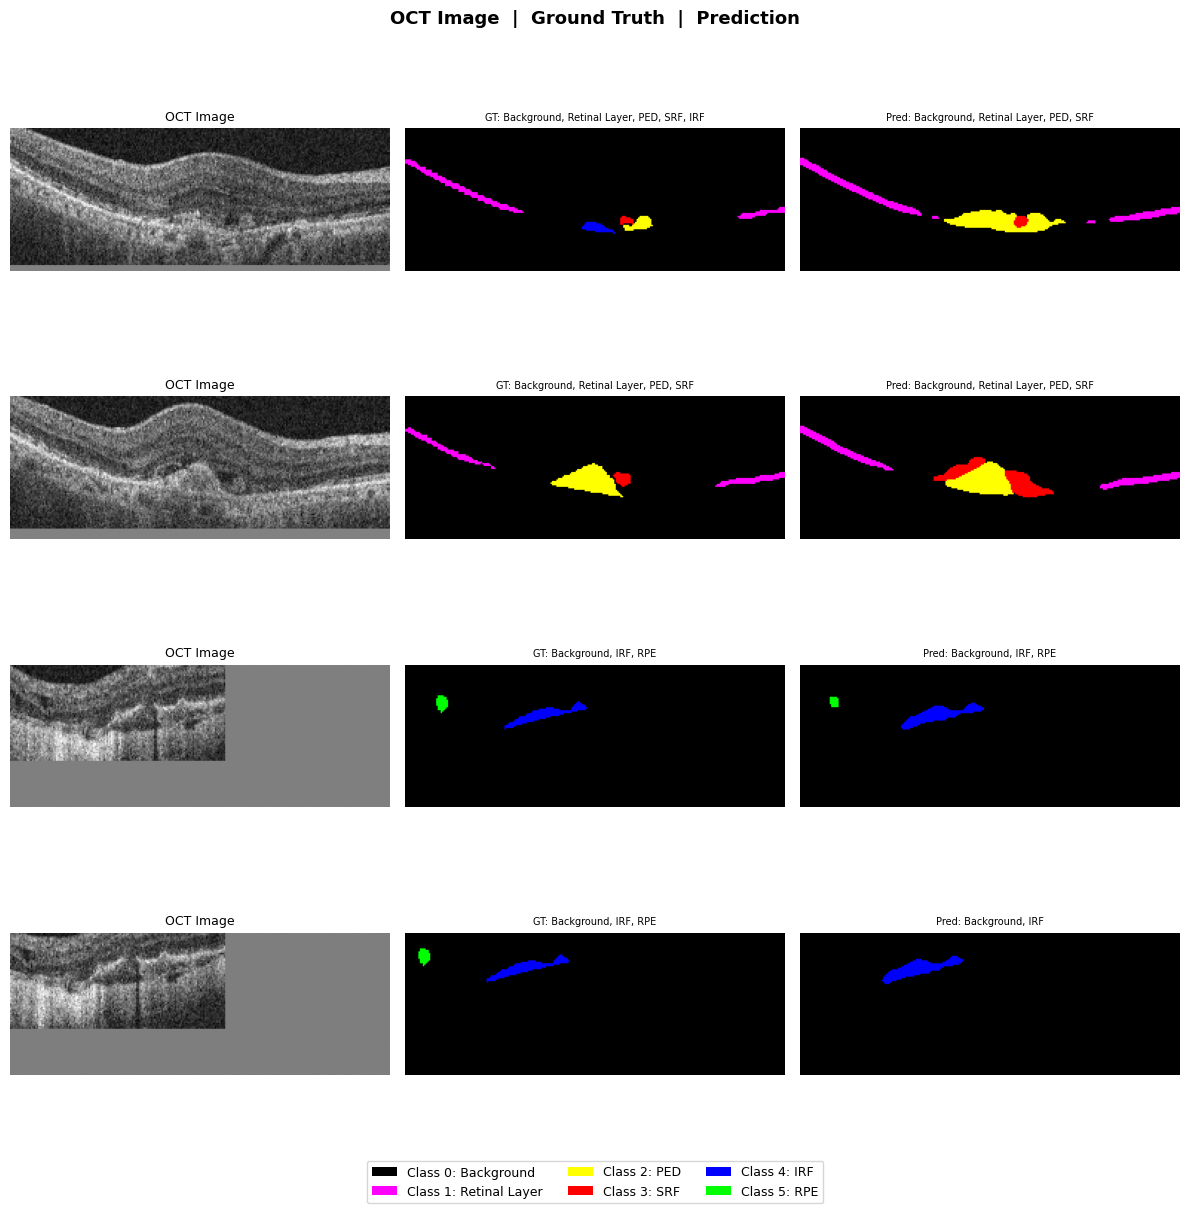

Saved → /content/drive/MyDrive/FYP/FineTune_new/finetune_roi_predictions_sample.png

── Per-Class Dice (this batch) ───────────────────────────────────
  Background         0.9902  ████████████████████████
  Retinal Layer      0.8033  ████████████████████
  PED                0.6443  ████████████████
  SRF                0.3306  ████████
  IRF                0.7552  ██████████████████
  RPE                0.3575  ████████


In [ ]:
# ── Grab one test batch ───────────────────────────────────────────────────────
model.eval()
imgs, masks = next(iter(test_loader))

with torch.no_grad():
    preds = model(imgs.to(device)).argmax(dim=1).cpu()

n_show = min(6, len(imgs))

fig, axes = plt.subplots(n_show, 3, figsize=(12, n_show * 3))
if n_show == 1:
    axes = axes[np.newaxis, :]
fig.suptitle("OCT Image  |  Ground Truth  |  Prediction",
             fontsize=13, fontweight="bold")

for i in range(n_show):
    img_np  = imgs[i].squeeze().numpy()
    mask_np = masks[i].numpy()
    pred_np = preds[i].numpy()

    gt_classes   = [CLASS_NAMES[c] for c in np.unique(mask_np) if c < NUM_CLASSES]
    pred_classes = [CLASS_NAMES[c] for c in np.unique(pred_np) if c < NUM_CLASSES]

    axes[i, 0].imshow(img_np, cmap="gray")
    axes[i, 0].set_title("OCT Image", fontsize=9)

    axes[i, 1].imshow(mask_to_rgb(mask_np))
    axes[i, 1].set_title(f"GT: {', '.join(gt_classes)}", fontsize=7)

    axes[i, 2].imshow(mask_to_rgb(pred_np))
    axes[i, 2].set_title(f"Pred: {', '.join(pred_classes)}", fontsize=7)

    for ax in axes[i]:
        ax.axis("off")

# ── Colour legend ─────────────────────────────────────────────────────────────
legend_elements = [
    Patch(facecolor=np.array(CLASS_COLORS_VIZ[i]) / 255,
          label=f"Class {i}: {CLASS_NAMES[i]}")
    for i in range(NUM_CLASSES)
]
fig.legend(handles=legend_elements, loc="lower center",
           ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.02))

vis_path = "/content/drive/MyDrive/FYP/FineTune_new/finetune_roi_predictions_sample.png"
plt.tight_layout()
plt.savefig(vis_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {vis_path}")

# ── Per-class Dice on this batch ──────────────────────────────────────────────
print("\n── Per-Class Dice (this batch) ───────────────────────────────────")
with torch.no_grad():
    preds_logits = model(imgs.to(device))
batch_dice = per_class_dice(preds_logits.detach(), masks.to(device))
for name, score in zip(CLASS_NAMES, batch_dice):
    bar = "█" * int(score * 25)
    print(f"  {name:<18} {score:.4f}  {bar}")

## Step 12 — Save Bulk Predictions

Saves a colour-coded prediction PNG for every image in the test set.  
File naming: `pred_0000.png`, `pred_0001.png`, ...


In [ ]:
pred_dir = CONFIG["pred_dir"]
os.makedirs(pred_dir, exist_ok=True)

model.eval()
saved = 0

with torch.no_grad():
    for imgs, masks in test_loader:
        preds = model(imgs.to(device)).argmax(dim=1).cpu().numpy()
        for pred in preds:
            rgb = mask_to_rgb(pred)
            cv2.imwrite(
                os.path.join(pred_dir, f"pred_{saved:04d}.png"),
                cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
            )
            saved += 1

print(f"Saved {saved} predictions → {pred_dir}")

Saved 728 predictions → /content/drive/MyDrive/FYP/FineTune_new/finetune_roi_predictions
